# 04 — Análise dos Resultados

**Projeto:** Avaliação Automática de Dificuldade em Jogos Atari com Deep RL
**Disciplina:** Redes Neurais Artificiais — PPGCC/UNESP

Consolida os logs dos 36 treinos (3 algoritmos × 4 jogos × 3 seeds) em
métricas agregadas, tabelas, figuras e testes estatísticos, alimentando as
seções *Experimentos e Resultados* e *Conclusões* do artigo.

**Premissa:** os 3 notebooks de treino (01, 02, 03) já foram executados e
os arquivos `*_eval.csv` em `logs/{algo}/` + modelos finais em
`models/{algo}/` existem.

**Hipótese central (H1):** as métricas de desempenho dos agentes correlacionam-se
com a dificuldade canônica dos jogos (Pong < Breakout < Ms.Pac-Man < Montezuma),
validável via ρ de Spearman.

## Instalação

In [ ]:
# --- 1. Instalação ---
# Stack moderna real: gymnasium + ale-py + stable-baselines3.
# ale-py ≥ 0.10 (2024+) traz as ROMs do Atari empacotadas — sem AutoROM.
#
# Idempotente: detecta o que já está instalado e pula. Se algo for
# instalado/atualizado AGORA, reinicia o kernel automaticamente para
# evitar conflito numpy-em-memória vs numpy-em-disco (bug clássico do Colab).

import sys, os, subprocess, importlib.util, platform, time

print(f"Python: {sys.version.split()[0]} | {platform.system()} {platform.machine()}")
assert sys.version_info >= (3, 10), (
    "Requer Python ≥ 3.10. No Colab default (3.11+) funciona; "
    "em outra máquina suba para 3.10/3.11/3.12."
)

def _sh(cmd: str) -> int:
    print(f"$ {cmd}")
    r = subprocess.run(cmd, shell=True, capture_output=True, text=True)
    if r.returncode != 0:
        print((r.stderr or r.stdout)[-800:])
    return r.returncode

def _has(pkg: str) -> bool:
    return importlib.util.find_spec(pkg) is not None

_RESTART_FLAG = "/tmp/.atari_drl_restart_done"
already_restarted = os.path.exists(_RESTART_FLAG)
installed_new = False

# 1) gymnasium + ale-py (ROMs embutidas) + stable-baselines3
if not (_has("ale_py") and _has("gymnasium") and _has("stable_baselines3")):
    print("► instalando gymnasium + ale-py + stable-baselines3...")
    _sh('pip install --quiet "gymnasium>=1.0.0" "ale-py>=0.10.0" '
        '"stable-baselines3>=2.4.0" "torch>=2.4"')
    installed_new = True

# 2) Análise + visualização
if not (_has("imageio") and _has("seaborn") and _has("cv2") and _has("scipy")):
    print("► instalando análise + viz...")
    _sh('pip install --quiet "opencv-python-headless" "imageio[ffmpeg]" '
        'tensorboard pandas scipy matplotlib seaborn tqdm rich psutil')
    installed_new = True

# 3) Restart obrigatório se algo foi instalado
if installed_new and not already_restarted:
    open(_RESTART_FLAG, "w").write("1")
    print()
    print("=" * 64)
    print("⚠  PACOTES NOVOS INSTALADOS — REINICIANDO O KERNEL")
    print("   (necessário para numpy/torch recarregarem coerentes)")
    print()
    print("   Após o restart automático: RE-EXECUTE ESTA CÉLULA.")
    print("   Na 2ª execução pula tudo e segue direto para validação.")
    print("=" * 64)
    time.sleep(3)
    os.kill(os.getpid(), 9)   # força restart no Colab/Jupyter

# 4) Validação (só executa se nada foi instalado nesta passagem)
print()
import torch, gymnasium as gym
import ale_py
import stable_baselines3 as sb3
print(f"✓ torch {torch.__version__} | CUDA: {torch.cuda.is_available()}"
      + (f" | GPU: {torch.cuda.get_device_name(0)}" if torch.cuda.is_available() else ""))
print(f"✓ gymnasium {gym.__version__} | ale-py {ale_py.__version__} | sb3 {sb3.__version__}")

# 5) Smoke test do env: ALE/Pong-v5
gym.register_envs(ale_py)    # registra ALE/<game>-v5 no namespace gymnasium
_env = gym.make("ALE/Pong-v5", render_mode="rgb_array")
_obs, _info = _env.reset(seed=0)
_obs, _r, _term, _trunc, _info = _env.step(_env.action_space.sample())
print(f"✓ env smoke test: obs={_obs.shape}, "
      f"action_space={_env.action_space}, "
      f"info_keys={sorted(_info)[:6]}")
_env.close()

# Limpa flag (próxima execução completa também é válida)
try: os.remove(_RESTART_FLAG)
except OSError: pass

print("\n✓✓ Ambiente pronto.")


Python: 3.12.13 | Linux x86_64
► instalando gymnasium + ale-py + stable-baselines3...
$ pip install --quiet "gymnasium>=1.0.0" "ale-py>=0.10.0" "stable-baselines3>=2.4.0" "torch>=2.4"

⚠  PACOTES NOVOS INSTALADOS — REINICIANDO O KERNEL
   (necessário para numpy/torch recarregarem coerentes)

   Após o restart automático: RE-EXECUTE ESTA CÉLULA.
   Na 2ª execução pula tudo e segue direto para validação.


## 1. Setup

In [1]:
# --- 1. Setup ---
import os, sys, csv, json
from pathlib import Path
from itertools import combinations

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import imageio.v2 as imageio

from scipy import stats

# RL stack (apenas para carregar modelos no render comparativo)
import torch
import gymnasium as gym
import ale_py

from stable_baselines3 import DQN, PPO, A2C
from stable_baselines3.common.atari_wrappers import AtariWrapper
from stable_baselines3.common.monitor import Monitor
from stable_baselines3.common.vec_env import (
    DummyVecEnv, VecFrameStack, VecTransposeImage
)

gym.register_envs(ale_py)

sns.set_theme(style="whitegrid", context="paper", font_scale=1.1)
plt.rcParams["figure.dpi"] = 110
plt.rcParams["savefig.bbox"] = "tight"
plt.rcParams["savefig.dpi"] = 200
PALETTE = {"DQN": "#1f77b4", "PPO": "#d62728", "A2C": "#2ca02c"}

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print(f"✓ Imports OK | device={DEVICE}")


✓ Imports OK | device=cpu


Gym has been unmaintained since 2022 and does not support NumPy 2.0 amongst other critical functionality.
Please upgrade to Gymnasium, the maintained drop-in replacement of Gym, or contact the authors of your software and request that they upgrade.
See the migration guide at https://gymnasium.farama.org/introduction/migration_guide/ for additional information.
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


## 2. Configuração

In [2]:
# --- 2. Paths + protocolo ---
IN_COLAB = "google.colab" in sys.modules
if IN_COLAB:
    try:
        from google.colab import drive
        if not os.path.ismount("/content/drive"):
            drive.mount("/content/drive", force_remount=False)
        BASE_DIR = Path("/content/drive/MyDrive/atari_drl_results")
    except Exception:
        BASE_DIR = Path("/content/atari_drl_results")
else:
    BASE_DIR = Path("./atari_drl_results").resolve()

MODELS_DIR = BASE_DIR / "models"
LOGS_DIR   = BASE_DIR / "logs"
FIGS_DIR   = BASE_DIR / "figures"
VIDS_DIR   = BASE_DIR / "videos"
for d in [FIGS_DIR, VIDS_DIR]:
    d.mkdir(parents=True, exist_ok=True)

# Protocolo experimental
GAMES = [
    ("ALE/Pong-v5",             "Pong",     1),
    ("ALE/Breakout-v5",         "Breakout", 2),
    ("ALE/MsPacman-v5",         "MsPacman", 3),
    ("ALE/MontezumaRevenge-v5", "Montezuma",4),
]
GAME_IDS    = {g[1]: g[0] for g in GAMES}
GAME_SHORTS = [g[1] for g in GAMES]
RANK_CANON  = {g[1]: g[2] for g in GAMES}

SEEDS  = [42, 123, 2024]
ALGOS  = ["DQN", "PPO", "A2C"]
TOTAL_TIMESTEPS = 500_000

# Baselines (Mnih 2015) e limiares de sucesso (definidos no notebook de treino)
HUMAN_BASELINE = {
    "Pong":     9.3,
    "Breakout": 31.8,
    "MsPacman": 15693.0,
    "Montezuma":4753.0,
}
RANDOM_BASELINE = {
    "Pong":     -20.7,
    "Breakout":  1.7,
    "MsPacman":  307.3,
    "Montezuma": 0.0,
}
SUCCESS_THRESHOLD = {
    "Pong":      0.0,
    "Breakout":  30.0,
    "MsPacman":  1000.0,
    "Montezuma": 400.0,
}

print(f"BASE: {BASE_DIR}")
print(f"Protocolo: {len(GAMES)} jogos × {len(SEEDS)} seeds × {len(ALGOS)} algos = "
      f"{len(GAMES)*len(SEEDS)*len(ALGOS)} runs")


Mounted at /content/drive
BASE: /content/drive/MyDrive/atari_drl_results
Protocolo: 4 jogos × 3 seeds × 3 algos = 36 runs


## 3. Carregamento dos logs de avaliação

In [3]:
# --- 3.1 Função de carregamento ---
def load_eval_logs(logs_root: Path) -> pd.DataFrame:
    """Lê todos os *_eval.csv em logs/{algo}/ e concatena em UM DataFrame.

    Schema (linha = 1 episódio de avaliação):
      algo, game, seed, timestep, ep_idx, ep_reward, ep_length, deaths, ts_iso
    """
    frames = []
    if not logs_root.exists():
        print(f"✗ pasta de logs não existe: {logs_root}")
        return pd.DataFrame()
    for algo_dir in sorted(logs_root.iterdir()):
        if not algo_dir.is_dir() or algo_dir.name == "tb":
            continue
        for csv_path in sorted(algo_dir.glob("*_eval.csv")):
            try:
                df = pd.read_csv(csv_path)
                df["timestep"]  = df["timestep"].astype(int)
                df["seed"]      = df["seed"].astype(int)
                df["game"]      = df["game"].astype(str)
                df["ep_reward"] = df["ep_reward"].astype(float)
                df["deaths"]    = df["deaths"].astype(int)
                frames.append(df)
            except Exception as e:
                print(f"  ✗ {csv_path.name}: {e}")
    if not frames:
        return pd.DataFrame()
    out = pd.concat(frames, ignore_index=True)
    out = out.sort_values(["algo", "game", "seed", "timestep", "ep_idx"]).reset_index(drop=True)
    return out

print("✓ load_eval_logs() definido")


✓ load_eval_logs() definido


In [4]:
# --- 3.2 Carregar dados ---
df = load_eval_logs(LOGS_DIR)
if df.empty:
    print("⚠️  Nenhum log encontrado. Rode os notebooks de treino primeiro.")
else:
    print(f"✓ {len(df):,} linhas (episódios) | "
          f"{df['algo'].nunique()} algos × {df['game'].nunique()} jogos × "
          f"{df['seed'].nunique()} seeds")
    print(f"  Timesteps: {df['timestep'].min():,} → {df['timestep'].max():,}")
    print(f"  Algos: {sorted(df['algo'].unique())}")
    print(f"  Jogos: {sorted(df['game'].unique())}")
    print(f"  Seeds: {sorted(df['seed'].unique())}")


✓ 42,621 linhas (episódios) | 3 algos × 4 jogos × 3 seeds
  Timesteps: 160 → 500,000
  Algos: ['A2C', 'DQN', 'PPO']
  Jogos: ['Breakout', 'Montezuma', 'MsPacman', 'Pong']
  Seeds: [np.int64(42), np.int64(123), np.int64(2024)]


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


## 4. Visão geral do dataset

In [ ]:
# --- 4. Visão geral ---
if df.empty:
    print("(sem dados — pulando)")
else:
    completude = (
        df.groupby(["algo", "game", "seed"])
          .size().reset_index(name="n_eval_eps")
          .pivot_table(index=["algo", "game"], columns="seed",
                       values="n_eval_eps", aggfunc="first", fill_value=0)
    )
    print("Episódios de avaliação registrados por (algo, game, seed):")
    print(completude)

    print("\nScore (recompensa real, sem clip) por episódio — descritiva:")
    print(df.groupby(["algo", "game"])["ep_reward"].describe()[["count", "mean", "50%", "std", "max"]])


Episódios de avaliação registrados por (algo, game, seed):
seed            42    123   2024
algo game                       
A2C  Breakout   3925  2260     0
     Pong        124  3905  3905
DQN  Breakout    250   250   250
     Montezuma   250   250   250
     MsPacman    250   250   250
     Pong          8   250   250
PPO  Breakout   1990  2220  1245
     Pong         64  1990  1990

Score (recompensa real, sem clip) por episódio — descritiva:
                 count         mean     50%         std     max
algo game                                                      
A2C  Breakout   6185.0     6.134034     5.0    4.583315    32.0
     Pong       7934.0   -20.995463   -21.0    0.072621   -19.0
DQN  Breakout    750.0    10.614667     9.0    8.832943    48.0
     Montezuma   750.0     0.000000     0.0    0.000000     0.0
     MsPacman    750.0  1328.973333  1265.0  676.623903  4740.0
     Pong        508.0   -15.122047   -16.0    5.205526     7.0
PPO  Breakout   5455.0     4.544821  

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


## 5. Métricas Grupo I — comparação entre arquiteturas

### 5.1 Definições (Grupo I — comparação entre arquiteturas)

Sejam $R(t)$ a recompensa média de avaliação no checkpoint de timestep $t$
e $T$ o total de timesteps de treino. Para cada $(\text{algo}, \text{game}, \text{seed})$:

- $\bar{R}_{\text{final}}$: média de $R$ nos últimos 50 000 timesteps
  (estado convergido)
- AUC normalizada: $\frac{1}{R_{\max} \cdot T}\int_0^T R(t)\, dt$, com
  $R_{\max}$ o máximo observado no run — escala $[0,1]$, mede eficiência amostral
- $t_{80\%}$: primeiro timestep em que $R(t) \geq 0{,}8 R_{\max}$
  (em frações de $T$; valor $\to 1$ se nunca atingir)
- $\sigma_{\text{final}}$: desvio-padrão de $R$ nos últimos 50 000 timesteps
  (estabilidade)

In [5]:
# --- 5.1 Cálculo Grupo I ---
def compute_group1_metrics(df_run: pd.DataFrame,
                            total_timesteps: int = TOTAL_TIMESTEPS,
                            window: int = 50_000) -> dict:
    """Para um único run (algo, game, seed), retorna métricas Grupo I."""
    if df_run.empty:
        return dict(R_final=np.nan, AUC_norm=np.nan, t80=np.nan, sigma_final=np.nan)
    # Agrega múltiplos eps por checkpoint usando MEDIANA
    g = df_run.groupby("timestep")["ep_reward"].median().sort_index()
    ts = g.index.values.astype(float)
    R  = g.values.astype(float)

    R_max = float(R.max()) if R.size else 0.0

    # R_final: janela final
    mask_final = ts >= (total_timesteps - window)
    R_final = float(np.mean(R[mask_final])) if mask_final.any() else float(R[-1])

    # σ_final: desvio sobre episódios na janela
    df_window = df_run[df_run["timestep"] >= (total_timesteps - window)]
    sigma_final = float(df_window["ep_reward"].std(ddof=1)) if len(df_window) > 1 else 0.0

    # AUC normalizada
    # NumPy 2.0+ renomeou trapz → trapezoid; compatibilidade dupla.
    _trapz = getattr(np, "trapezoid", None) or np.trapz
    if R_max > 0 and ts.max() > ts.min():
        auc = _trapz(R, ts) / (R_max * total_timesteps)
    elif R_max < 0 and ts.max() > ts.min():
        # Para Pong com scores negativos: normaliza por |R_max|*T
        auc = _trapz(R, ts) / (abs(R_max) * total_timesteps)
    else:
        auc = 0.0

    # t80: primeiro ts com R(t) ≥ 0.8 * R_max
    threshold = 0.8 * R_max
    if R_max > 0:
        above = np.where(R >= threshold)[0]
    elif R_max < 0:
        # Pong: "atingir 80% do máximo" = chegar próximo do score positivo
        above = np.where(R >= threshold)[0]
    else:
        above = np.array([])
    if above.size and R_max != 0:
        t80 = float(ts[above[0]]) / total_timesteps
    else:
        t80 = 1.0

    return dict(R_final=R_final, AUC_norm=float(auc), t80=t80, sigma_final=sigma_final)


def build_group1_table(df: pd.DataFrame) -> pd.DataFrame:
    rows = []
    for (algo, game, seed), sub in df.groupby(["algo", "game", "seed"]):
        m = compute_group1_metrics(sub)
        rows.append(dict(algo=algo, game=game, seed=seed, **m))
    return pd.DataFrame(rows)

if not df.empty:
    g1_run = build_group1_table(df)
    print(f"✓ Métricas Grupo I computadas para {len(g1_run)} runs")
    print(g1_run.head(8).to_string(index=False))
else:
    g1_run = pd.DataFrame()


✓ Métricas Grupo I computadas para 30 runs
algo     game  seed    R_final  AUC_norm     t80  sigma_final
 A2C Breakout    42   5.948718  0.270312 0.40832     4.619023
 A2C Breakout   123  15.858974  0.299748 0.57344     5.595901
 A2C Breakout  2024   5.000000  0.065536 0.14976     0.000000
 A2C     Pong    42 -21.000000 -0.019520 1.00000     0.000000
 A2C     Pong   123 -21.000000 -1.048256 1.00000     0.112644
 A2C     Pong  2024 -21.000000 -1.048256 1.00000     0.087480
 DQN Breakout    42  17.666667  0.400800 0.70000     7.654088
 DQN Breakout   123   8.000000  0.374444 0.44000     8.027897


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


## 5.2 Tabela Grupo I (mediana ± IQR sobre 3 seeds)

In [6]:
# --- 5.2 Tabela Grupo I (mediana ± IQR sobre 3 seeds) ---
def aggregate_iqr(series: pd.Series) -> str:
    if len(series) == 0 or series.isna().all():
        return "—"
    med = float(series.median())
    q1, q3 = float(series.quantile(0.25)), float(series.quantile(0.75))
    return f"{med:.2f} (IQR {q1:.2f}–{q3:.2f})"

if not g1_run.empty:
    g1_agg = (
        g1_run
        .groupby(["algo", "game"])
        .agg({"R_final":   aggregate_iqr,
              "AUC_norm":  aggregate_iqr,
              "t80":       aggregate_iqr,
              "sigma_final": aggregate_iqr})
        .reset_index()
    )
    # Ordena na ordem canônica dos jogos
    g1_agg["game"] = pd.Categorical(g1_agg["game"], categories=GAME_SHORTS, ordered=True)
    g1_agg = g1_agg.sort_values(["algo", "game"])
    print("Tabela Grupo I — mediana (IQR) sobre 3 seeds:")
    print(g1_agg.to_string(index=False))
    g1_agg.to_csv(FIGS_DIR / "table_group1.csv", index=False)
    print(f"\n✓ exportado: {FIGS_DIR / 'table_group1.csv'}")


Tabela Grupo I — mediana (IQR) sobre 3 seeds:
algo      game                       R_final                AUC_norm                  t80                sigma_final
 A2C      Pong    -21.00 (IQR -21.00–-21.00) -1.05 (IQR -1.05–-0.53) 1.00 (IQR 1.00–1.00)       0.09 (IQR 0.04–0.10)
 A2C  Breakout         5.95 (IQR 5.47–10.90)    0.27 (IQR 0.17–0.29) 0.41 (IQR 0.28–0.49)       4.62 (IQR 2.31–5.11)
 DQN      Pong    -10.17 (IQR -15.58–-10.08) -2.46 (IQR -2.75–-1.24) 1.00 (IQR 1.00–1.00)       3.60 (IQR 1.80–4.70)
 DQN  Breakout       17.67 (IQR 12.83–19.17)    0.40 (IQR 0.39–0.43) 0.58 (IQR 0.51–0.64)       8.03 (IQR 7.84–8.72)
 DQN  MsPacman 1873.33 (IQR 1864.17–1881.67)    0.48 (IQR 0.46–0.51) 0.64 (IQR 0.58–0.72) 520.60 (IQR 485.81–644.10)
 DQN Montezuma          0.00 (IQR 0.00–0.00)    0.00 (IQR 0.00–0.00) 1.00 (IQR 1.00–1.00)       0.00 (IQR 0.00–0.00)
 PPO      Pong    -20.90 (IQR -20.95–-20.64) -1.10 (IQR -1.13–-0.56) 1.00 (IQR 1.00–1.00)       0.61 (IQR 0.30–0.97)
 PPO  Breakout    

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)



✓ exportado: /content/drive/MyDrive/atari_drl_results/figures/table_group1.csv


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


## 5.3 Curvas de aprendizado

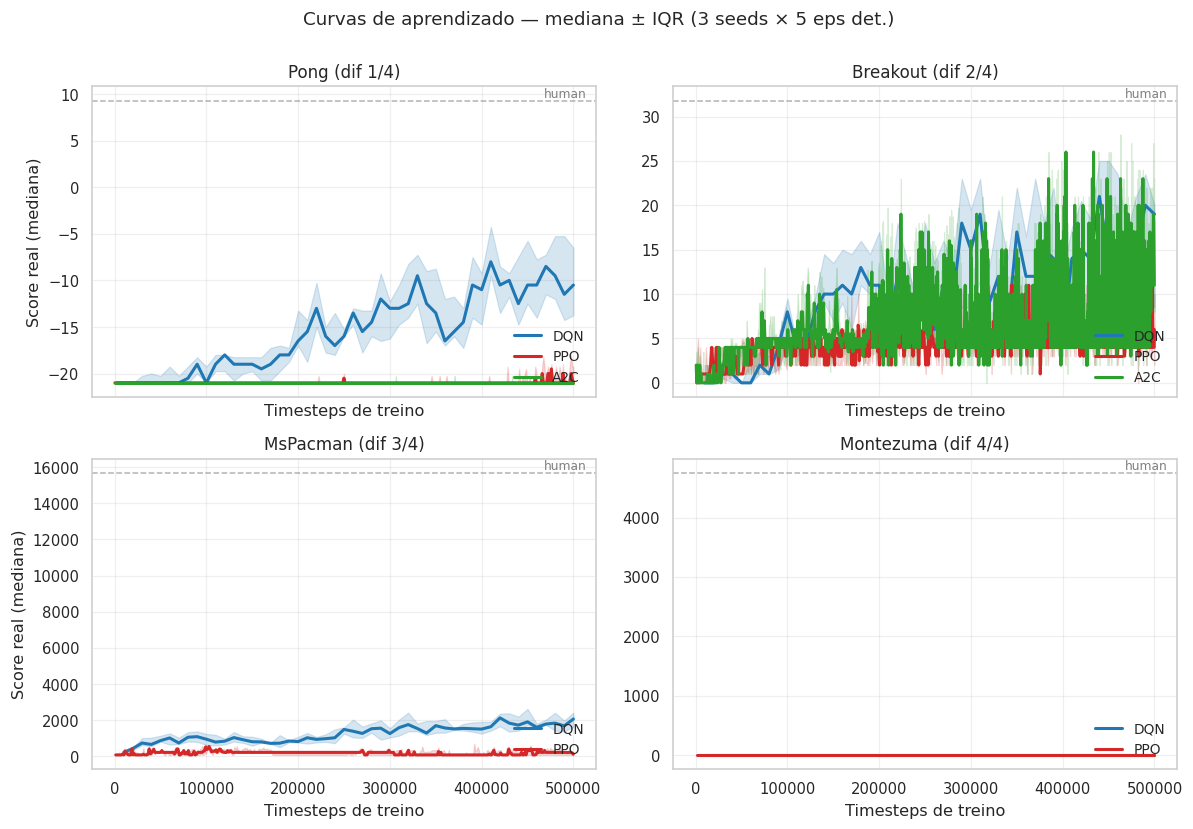

✓ salvo: /content/drive/MyDrive/atari_drl_results/figures/learning_curves.png


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


In [7]:
# --- 5.3 Curvas de aprendizado (1 subplot por jogo, 3 linhas/algos) ---
if df.empty:
    print("(sem dados)")
else:
    fig, axes = plt.subplots(2, 2, figsize=(11, 7.5), sharex=True)
    axes = axes.flatten()
    for i, game in enumerate(GAME_SHORTS):
        ax = axes[i]
        for algo in ALGOS:
            sub = df[(df["algo"] == algo) & (df["game"] == game)]
            if sub.empty:
                continue
            agg = sub.groupby("timestep")["ep_reward"].agg(["median"]).reset_index()
            agg["q1"] = sub.groupby("timestep")["ep_reward"].quantile(0.25).values
            agg["q3"] = sub.groupby("timestep")["ep_reward"].quantile(0.75).values
            ax.plot(agg["timestep"], agg["median"], color=PALETTE[algo],
                    label=algo, linewidth=2.0)
            ax.fill_between(agg["timestep"], agg["q1"], agg["q3"],
                            color=PALETTE[algo], alpha=0.18)
        # Anotações de baselines
        if game in HUMAN_BASELINE:
            ax.axhline(HUMAN_BASELINE[game], color="gray", linestyle="--",
                       alpha=0.6, linewidth=1)
            ax.text(0.98, HUMAN_BASELINE[game], "human", ha="right",
                    va="bottom", transform=ax.get_yaxis_transform(),
                    fontsize=8, color="gray")
        ax.set_title(f"{game} (dif {RANK_CANON[game]}/4)", fontsize=11)
        ax.set_xlabel("Timesteps de treino")
        if i % 2 == 0:
            ax.set_ylabel("Score real (mediana)")
        ax.legend(loc="lower right", frameon=False, fontsize=9)
        ax.grid(alpha=0.3)
    fig.suptitle("Curvas de aprendizado — mediana ± IQR (3 seeds × 5 eps det.)",
                 fontsize=12, y=1.00)
    fig.tight_layout()
    out = FIGS_DIR / "learning_curves.png"
    fig.savefig(out); plt.show()
    print(f"✓ salvo: {out}")


## 5.4 Boxplots comparativos Grupo I

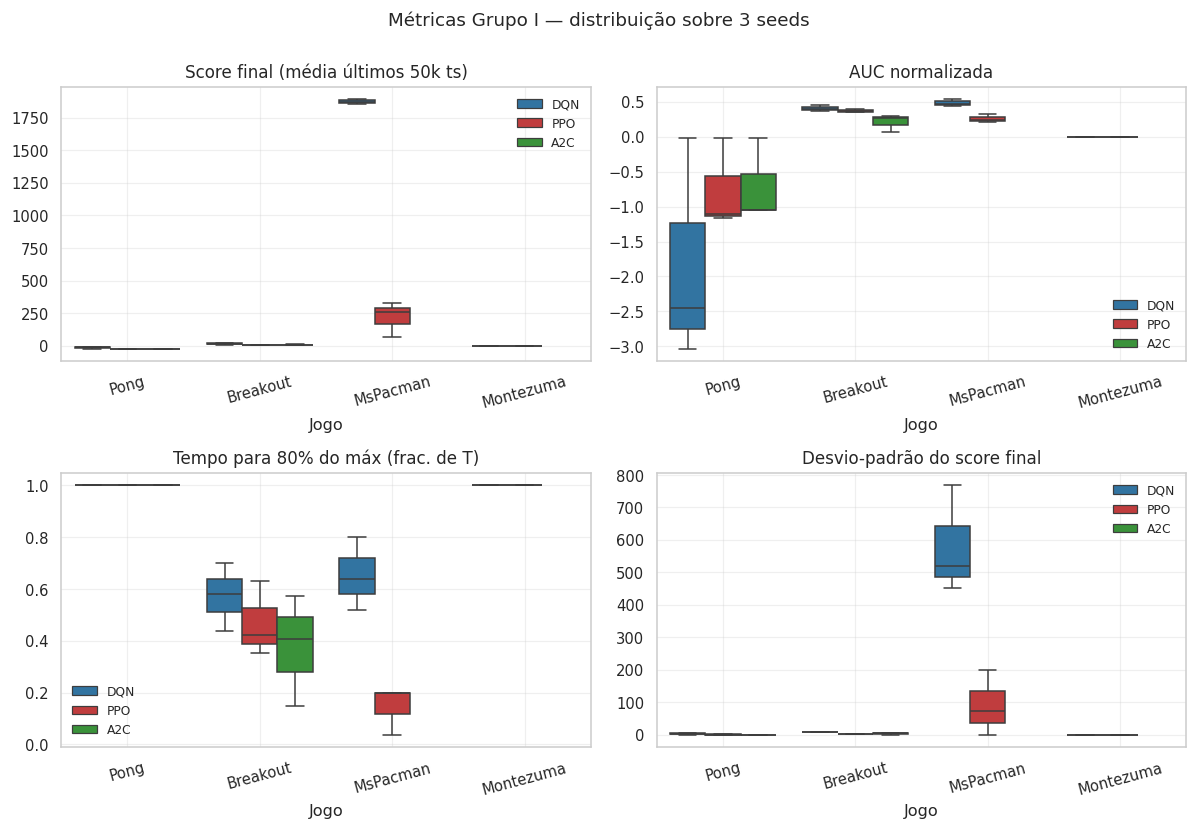

✓ salvo: /content/drive/MyDrive/atari_drl_results/figures/group1_bars.png


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


In [8]:
# --- 5.4 Boxplots comparativos Grupo I ---
if not g1_run.empty:
    g1_run = g1_run.copy()
    g1_run["game"] = pd.Categorical(g1_run["game"], categories=GAME_SHORTS, ordered=True)
    metric_titles = {
        "R_final":     "Score final (média últimos 50k ts)",
        "AUC_norm":    "AUC normalizada",
        "t80":         "Tempo para 80% do máx (frac. de T)",
        "sigma_final": "Desvio-padrão do score final",
    }
    fig, axes = plt.subplots(2, 2, figsize=(11, 7.5))
    axes = axes.flatten()
    for i, (metric, title) in enumerate(metric_titles.items()):
        ax = axes[i]
        sns.boxplot(data=g1_run, x="game", y=metric, hue="algo",
                    order=GAME_SHORTS, hue_order=ALGOS, palette=PALETTE, ax=ax)
        ax.set_title(title, fontsize=11)
        ax.set_xlabel("Jogo"); ax.set_ylabel("")
        ax.tick_params(axis='x', rotation=15)
        ax.legend(title="", frameon=False, fontsize=8, loc="best")
        ax.grid(alpha=0.3)
    fig.suptitle("Métricas Grupo I — distribuição sobre 3 seeds",
                 fontsize=12, y=1.00)
    fig.tight_layout()
    out = FIGS_DIR / "group1_bars.png"
    fig.savefig(out); plt.show()
    print(f"✓ salvo: {out}")


## 6. Métricas Grupo II — dificuldade

### 6.1 Definições (Grupo II — dificuldade)

Análogo às métricas originais do Mario, adaptadas para Atari. Considerando os
episódios determinísticos do **último checkpoint** (proxy do agente convergido):

- **$\tau$ — taxa de sucesso**: fração de episódios em que o score atinge um
  limiar pré-definido por jogo (análogo a "conclusão da fase"):
  - Pong: score > 0 (vencer o jogo)
  - Breakout: score ≥ 30 (~quebrar 30 blocos)
  - Ms.Pac-Man: score ≥ 1000
  - Montezuma: score ≥ 400 (~pegar a 1ª chave)

- **$\bar{d}$ — score humano-normalizado** (Mnih 2015, Eq. 1):
  $$\bar{d} = \frac{\text{score}_{\text{agent}} - \text{score}_{\text{random}}}
                  {\text{score}_{\text{human}} - \text{score}_{\text{random}}}$$
  Valor 1.0 = nível humano; 0.0 = aleatório. Análogo à distância normalizada da fase.

- **Mortes**: vidas perdidas por episódio (`info['lives']` do AtariWrapper).

- **Tempo**: passos da política × 4 frames (frame skip) — *proxy* para "duração"
  do episódio, equivalente ao tempo de fase do Mario.

In [ ]:
# --- 6.1 Cálculo Grupo II ---
def last_checkpoint_episodes(df_run: pd.DataFrame) -> pd.DataFrame:
    if df_run.empty:
        return df_run
    last_ts = df_run["timestep"].max()
    return df_run[df_run["timestep"] == last_ts].copy()


def compute_group2_metrics(df_run: pd.DataFrame, game: str) -> dict:
    last = last_checkpoint_episodes(df_run)
    if last.empty:
        return dict(tau=np.nan, d_bar=np.nan, deaths_med=np.nan,
                    time_frames=np.nan, n_eps=0)

    threshold = SUCCESS_THRESHOLD.get(game, 0.0)
    tau   = float((last["ep_reward"] >= threshold).mean())

    # d̄: score humano-normalizado (média sobre os 5 eps de avaliação)
    hb, rb = HUMAN_BASELINE.get(game, 1.0), RANDOM_BASELINE.get(game, 0.0)
    denom  = (hb - rb) if (hb - rb) != 0 else 1.0
    d_bar  = float(((last["ep_reward"].mean() - rb) / denom))

    deaths_med  = float(last["deaths"].median())
    # tempo: ep_length (steps da policy) × 4 (frame_skip) = frames reais
    time_frames = float(last["ep_length"].median() * 4)

    return dict(tau=tau, d_bar=d_bar, deaths_med=deaths_med,
                time_frames=time_frames, n_eps=int(len(last)))


def build_group2_table(df: pd.DataFrame) -> pd.DataFrame:
    rows = []
    for (algo, game, seed), sub in df.groupby(["algo", "game", "seed"]):
        m = compute_group2_metrics(sub, game)
        rows.append(dict(algo=algo, game=game, seed=seed, **m))
    return pd.DataFrame(rows)

if not df.empty:
    g2_run = build_group2_table(df)
    print(f"✓ Métricas Grupo II computadas para {len(g2_run)} runs")
    print(g2_run.head(8).to_string(index=False))
else:
    g2_run = pd.DataFrame()


✓ Métricas Grupo II computadas para 12 runs
algo     game  seed  tau     d_bar  deaths_med  time_frames  n_eps
 A2C Breakout    42  0.0 -0.043189         1.0      26980.0      5
 A2C     Pong    42  0.0 -0.010000         0.0        732.0      2
 A2C     Pong   123  0.0 -0.010000         0.0        740.0      5
 A2C     Pong  2024  0.0 -0.003333         0.0        940.0      5
 DQN Breakout    42  0.0  0.116279         1.0      26988.0      5
 DQN     Pong    42  0.0 -0.010000         0.0        744.0      2
 DQN     Pong   123  0.0  0.296667         0.0       3560.0      5
 DQN     Pong  2024  0.0  0.410000         0.0       3628.0      5


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


## 6.2 Tabela Grupo II

In [ ]:
# --- 6.2 Tabela Grupo II (mediana ± IQR) ---
if not g2_run.empty:
    g2_agg = (
        g2_run
        .groupby(["algo", "game"])
        .agg({"tau":         aggregate_iqr,
              "d_bar":       aggregate_iqr,
              "deaths_med":  aggregate_iqr,
              "time_frames": aggregate_iqr})
        .reset_index()
    )
    g2_agg["game"] = pd.Categorical(g2_agg["game"], categories=GAME_SHORTS, ordered=True)
    g2_agg = g2_agg.sort_values(["algo", "game"])
    print("Tabela Grupo II — mediana (IQR) sobre 3 seeds:")
    print(g2_agg.to_string(index=False))
    g2_agg.to_csv(FIGS_DIR / "table_group2.csv", index=False)
    print(f"\n✓ exportado: {FIGS_DIR / 'table_group2.csv'}")


Tabela Grupo II — mediana (IQR) sobre 3 seeds:
algo     game                  tau                   d_bar           deaths_med                      time_frames
 A2C     Pong 0.00 (IQR 0.00–0.00) -0.01 (IQR -0.01–-0.01) 0.00 (IQR 0.00–0.00)       740.00 (IQR 736.00–840.00)
 A2C Breakout 0.00 (IQR 0.00–0.00) -0.04 (IQR -0.04–-0.04) 1.00 (IQR 1.00–1.00) 26980.00 (IQR 26980.00–26980.00)
 DQN     Pong 0.00 (IQR 0.00–0.00)    0.30 (IQR 0.14–0.35) 0.00 (IQR 0.00–0.00)    3560.00 (IQR 2152.00–3594.00)
 DQN Breakout 0.00 (IQR 0.00–0.00)    0.12 (IQR 0.12–0.12) 1.00 (IQR 1.00–1.00) 26988.00 (IQR 26988.00–26988.00)
 PPO     Pong 0.00 (IQR 0.00–0.00)    0.01 (IQR 0.00–0.02) 0.00 (IQR 0.00–0.00)    2096.00 (IQR 1422.00–2328.00)
 PPO Breakout 0.00 (IQR 0.00–0.00)    0.03 (IQR 0.03–0.03) 1.00 (IQR 1.00–1.00) 26976.00 (IQR 26976.00–26976.00)

✓ exportado: /content/drive/MyDrive/atari_drl_results/figures/table_group2.csv


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


## 6.3 Dificuldade por jogo (boxplots)

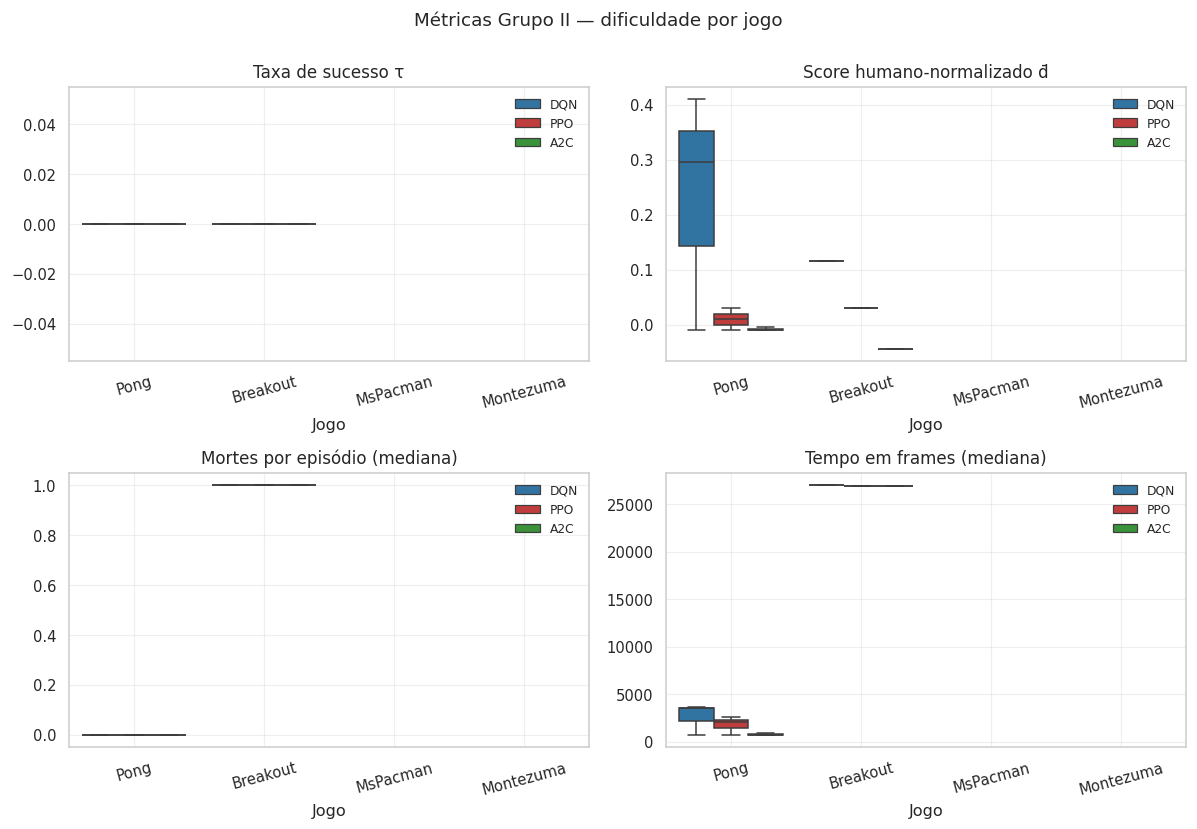

✓ salvo: /content/drive/MyDrive/atari_drl_results/figures/group2_boxplots.png


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


In [ ]:
# --- 6.3 Boxplots Grupo II (dificuldade por jogo) ---
if not g2_run.empty:
    g2_run = g2_run.copy()
    g2_run["game"] = pd.Categorical(g2_run["game"], categories=GAME_SHORTS, ordered=True)
    metric_titles = {
        "tau":         "Taxa de sucesso τ",
        "d_bar":       "Score humano-normalizado d̄",
        "deaths_med":  "Mortes por episódio (mediana)",
        "time_frames": "Tempo em frames (mediana)",
    }
    fig, axes = plt.subplots(2, 2, figsize=(11, 7.5))
    axes = axes.flatten()
    for i, (metric, title) in enumerate(metric_titles.items()):
        ax = axes[i]
        sns.boxplot(data=g2_run, x="game", y=metric, hue="algo",
                    order=GAME_SHORTS, hue_order=ALGOS, palette=PALETTE, ax=ax)
        ax.set_title(title, fontsize=11)
        ax.set_xlabel("Jogo"); ax.set_ylabel("")
        ax.tick_params(axis='x', rotation=15)
        ax.legend(title="", frameon=False, fontsize=8, loc="best")
        ax.grid(alpha=0.3)
    fig.suptitle("Métricas Grupo II — dificuldade por jogo",
                 fontsize=12, y=1.00)
    fig.tight_layout()
    out = FIGS_DIR / "group2_boxplots.png"
    fig.savefig(out); plt.show()
    print(f"✓ salvo: {out}")


## 7. Análise Estatística

### 7.1 Spearman — correlação com a dificuldade canônica

Ordenamos os jogos pela dificuldade **canônica** reconhecida na literatura de
RL (Mnih 2015, Bellemare 2016, Badia 2020):

| Rank | Jogo | Justificativa |
|------|------|---------------|
| 1 | Pong | Convergência rápida (~100k ts), reward denso |
| 2 | Breakout | Convergência moderada, reward semi-denso |
| 3 | Ms.Pac-Man | Espaço de estados grande, exploração ampla |
| 4 | Montezuma's Revenge | *Sparse reward* + *hard exploration* (não resolvido por DQN/PPO baseline) |

Para cada $(\text{algo}, \text{métrica})$, computamos $\rho$ de Spearman entre o
ranking canônico e o ranking induzido pela mediana da métrica sobre as 3 seeds.

- Métricas de "facilidade" ($\tau$, $\bar{d}$, $R_{\text{final}}$, AUC):
  esperamos $\rho < 0$ (jogo mais difícil → métrica menor)
- Métricas de "dificuldade" (mortes, $t_{80\%}$):
  esperamos $\rho > 0$ (jogo mais difícil → métrica maior)

$|\rho| \geq 0{,}8$ valida a hipótese H1 do projeto.

In [ ]:
# --- 7.1 Spearman ---
RANK_CANON_LOCAL = {"Pong": 1, "Breakout": 2, "MsPacman": 3, "Montezuma": 4}

# Sinal esperado: -1 = métrica deveria DECRESCER com dificuldade
#                 +1 = métrica deveria CRESCER com dificuldade
EXPECTED_SIGNS = {
    "tau": -1, "d_bar": -1, "deaths_med": +1, "time_frames": +1,
    "R_final": -1, "AUC_norm": -1, "t80": +1, "sigma_final": 0,
}

def spearman_per_algo(g1_run: pd.DataFrame, g2_run: pd.DataFrame) -> pd.DataFrame:
    """Computa ρ entre rank canônico e mediana da métrica por jogo, por algoritmo."""
    rows = []
    # Combina G1 e G2 num único DF largo por (algo, game, seed)
    if g1_run.empty and g2_run.empty:
        return pd.DataFrame()
    if not g1_run.empty and not g2_run.empty:
        merged = pd.merge(g1_run, g2_run, on=["algo", "game", "seed"], how="outer")
    else:
        merged = g1_run if not g1_run.empty else g2_run

    metrics = [m for m in EXPECTED_SIGNS if m in merged.columns]
    for algo in ALGOS:
        sub = merged[merged["algo"] == algo]
        if sub.empty:
            continue
        med = sub.groupby("game")[metrics].median().reindex(GAME_SHORTS)
        canonical = np.array([RANK_CANON_LOCAL[g] for g in med.index])
        for metric in metrics:
            vals = med[metric].values
            mask = ~np.isnan(vals)
            if mask.sum() < 3:
                rows.append(dict(algo=algo, metric=metric,
                                 rho=np.nan, p=np.nan, n=int(mask.sum()),
                                 expected_sign=EXPECTED_SIGNS[metric]))
                continue
            rho, p = stats.spearmanr(canonical[mask], vals[mask])
            rows.append(dict(algo=algo, metric=metric,
                             rho=float(rho), p=float(p), n=int(mask.sum()),
                             expected_sign=EXPECTED_SIGNS[metric]))
    out = pd.DataFrame(rows)
    if not out.empty:
        out["consistent"] = out.apply(
            lambda r: bool(np.sign(r["rho"]) == r["expected_sign"]
                            if r["expected_sign"] != 0 and not np.isnan(r["rho"])
                            else False),
            axis=1,
        )
    return out

if not df.empty:
    sp = spearman_per_algo(g1_run, g2_run)
    print("Spearman ρ entre rank canônico dos jogos e mediana da métrica:")
    print(sp.to_string(index=False))
    sp.to_csv(FIGS_DIR / "spearman.csv", index=False)
    print(f"\n✓ exportado: {FIGS_DIR / 'spearman.csv'}")
    consistent_n = sp["consistent"].sum() if "consistent" in sp else 0
    print(f"\nMétricas consistentes com o sinal esperado: {consistent_n}/{len(sp)}")
    print("|ρ| ≥ 0.8 valida H1: as métricas dos agentes refletem a dificuldade canônica.")


Spearman ρ entre rank canônico dos jogos e mediana da métrica:
algo      metric  rho   p  n  expected_sign  consistent
 DQN         tau  NaN NaN  2             -1       False
 DQN       d_bar  NaN NaN  2             -1       False
 DQN  deaths_med  NaN NaN  2              1       False
 DQN time_frames  NaN NaN  2              1       False
 DQN     R_final  NaN NaN  2             -1       False
 DQN    AUC_norm  NaN NaN  2             -1       False
 DQN         t80  NaN NaN  2              1       False
 DQN sigma_final  NaN NaN  2              0       False
 PPO         tau  NaN NaN  2             -1       False
 PPO       d_bar  NaN NaN  2             -1       False
 PPO  deaths_med  NaN NaN  2              1       False
 PPO time_frames  NaN NaN  2              1       False
 PPO     R_final  NaN NaN  2             -1       False
 PPO    AUC_norm  NaN NaN  2             -1       False
 PPO         t80  NaN NaN  2              1       False
 PPO sigma_final  NaN NaN  2             

/tmp/ipykernel_67698/1295876608.py:27: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  med = sub.groupby("game")[metrics].median().reindex(GAME_SHORTS)
/tmp/ipykernel_67698/1295876608.py:27: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  med = sub.groupby("game")[metrics].median().reindex(GAME_SHORTS)
/tmp/ipykernel_67698/1295876608.py:27: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  med = sub.groupby("game")[metrics].medi

### 7.2 Mann-Whitney U — comparação pareada de algoritmos

Para cada jogo, comparamos pareadamente os 3 algoritmos (DQN×PPO, DQN×A2C,
PPO×A2C) na recompensa final dos episódios do último checkpoint.

Mann-Whitney U é o teste não-paramétrico apropriado: não assume normalidade,
lida com pequenas amostras (3 seeds × 5 eps = 15 valores por algoritmo) e é o
padrão de fato em comparações de RL.

In [ ]:
# --- 7.2 Mann-Whitney U pareado por jogo ---
def mann_whitney_pairwise(df: pd.DataFrame, metric: str = "ep_reward") -> pd.DataFrame:
    rows = []
    for game in GAME_SHORTS:
        for a, b in combinations(ALGOS, 2):
            xa = df[(df["algo"] == a) & (df["game"] == game)][metric].values
            xb = df[(df["algo"] == b) & (df["game"] == game)][metric].values
            if len(xa) < 3 or len(xb) < 3:
                rows.append(dict(game=game, algo_a=a, algo_b=b,
                                 n_a=len(xa), n_b=len(xb),
                                 U=np.nan, p=np.nan,
                                 median_a=np.nan, median_b=np.nan))
                continue
            U, p = stats.mannwhitneyu(xa, xb, alternative="two-sided")
            rows.append(dict(
                game=game, algo_a=a, algo_b=b,
                n_a=int(len(xa)), n_b=int(len(xb)),
                U=float(U), p=float(p),
                median_a=float(np.median(xa)), median_b=float(np.median(xb)),
            ))
    return pd.DataFrame(rows)

if not df.empty:
    # Considera apenas eps do último checkpoint de cada run (mais estável)
    last_eps = df.loc[df.groupby(["algo", "game", "seed"])["timestep"]
                          .transform("max") == df["timestep"]]
    mw = mann_whitney_pairwise(last_eps, metric="ep_reward")
    mw["sig"] = mw["p"].apply(lambda p: "***" if p < 0.001 else
                              "**" if p < 0.01 else
                              "*" if p < 0.05 else "ns")
    print("Mann-Whitney U (ep_reward, último checkpoint):")
    print(mw.to_string(index=False))
    mw.to_csv(FIGS_DIR / "mann_whitney.csv", index=False)
    print(f"\n✓ exportado: {FIGS_DIR / 'mann_whitney.csv'}")


Mann-Whitney U (ep_reward, último checkpoint):
     game algo_a algo_b  n_a  n_b     U        p  median_a  median_b sig
     Pong    DQN    PPO   12   12 127.0 0.001085     -12.5     -21.0  **
     Pong    DQN    A2C   12   12 131.0 0.000231     -12.5     -21.0 ***
     Pong    PPO    A2C   12   12  91.5 0.122110     -21.0     -21.0  ns
 Breakout    DQN    PPO    5    5  17.5 0.289587       4.0       4.0  ns
 Breakout    DQN    A2C    5    5  24.5 0.011751       4.0       0.0   *
 Breakout    PPO    A2C    5    5  21.0 0.070640       4.0       0.0  ns
 MsPacman    DQN    PPO    0    0   NaN      NaN       NaN       NaN  ns
 MsPacman    DQN    A2C    0    0   NaN      NaN       NaN       NaN  ns
 MsPacman    PPO    A2C    0    0   NaN      NaN       NaN       NaN  ns
Montezuma    DQN    PPO    0    0   NaN      NaN       NaN       NaN  ns
Montezuma    DQN    A2C    0    0   NaN      NaN       NaN       NaN  ns
Montezuma    PPO    A2C    0    0   NaN      NaN       NaN       NaN  ns

✓ e

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


## 8. Comparação visual lado-a-lado (DQN × PPO × A2C)

In [ ]:
# --- 8. GIF lado-a-lado: DQN × PPO × A2C no mesmo jogo ---
# Mesmo seed de avaliação → mesmo estado inicial → comparação justa.

def _ensure_cv2():
    """cv2 é usado apenas no overlay de labels. Lazy import + auto-install."""
    try:
        import cv2 as _cv2
        return _cv2
    except ImportError:
        import subprocess
        subprocess.run("pip install --quiet opencv-python-headless",
                       shell=True, check=True)
        import cv2 as _cv2
        return _cv2


def _build_env_for_render(game_id: str, seed: int):
    raw_holder = {}
    def _thunk():
        import gymnasium as _gym
        import ale_py as _ale
        from stable_baselines3.common.atari_wrappers import AtariWrapper as _AW
        from stable_baselines3.common.monitor import Monitor as _Mon
        _gym.register_envs(_ale)
        env = _gym.make(game_id, render_mode="rgb_array")
        raw_holder["env"] = env
        env = _AW(env, noop_max=30, frame_skip=4, screen_size=84,
                  terminal_on_life_loss=False, clip_reward=False)
        env = _Mon(env)
        return env
    venv = DummyVecEnv([_thunk])
    venv = VecFrameStack(venv, n_stack=4, channels_order="last")
    venv = VecTransposeImage(venv)
    venv.seed(seed)
    return venv, raw_holder["env"]


_LOAD = {"DQN": DQN, "PPO": PPO, "A2C": A2C}


def render_models_side_by_side(game: str, seed_eval: int = 999,
                                seed_model: int = 42,
                                max_steps: int = 3000, fps: int = 30,
                                save_path=None) -> list:
    """Carrega DQN, PPO e A2C (mesmo jogo/seed_model) e renderiza em paralelo."""
    cv2 = _ensure_cv2()
    game_id = GAME_IDS[game]
    venvs, raws, models = {}, {}, {}
    for algo in ALGOS:
        path = MODELS_DIR / algo / f"{algo}_{game}_{seed_model}.zip"
        if not path.exists():
            print(f"  ⚠ {path.name} não existe — pulando {algo}")
            continue
        venv, raw = _build_env_for_render(game_id, seed_eval)
        venvs[algo] = venv; raws[algo] = raw
        models[algo] = _LOAD[algo].load(path, device=DEVICE)

    if not models:
        print("(sem modelos disponíveis)"); return []

    obs_dict  = {a: venvs[a].reset() for a in models}
    done_dict = {a: False for a in models}
    composite_frames = []

    for _ in range(max_steps):
        panels = []
        for algo in ALGOS:
            if algo not in models:
                panels.append(np.full((210, 160, 3), 60, dtype=np.uint8))
                continue
            if done_dict[algo]:
                f = raws[algo].render()
            else:
                action, _ = models[algo].predict(obs_dict[algo], deterministic=True)
                obs_dict[algo], _r, dn, _i = venvs[algo].step(action)
                if dn[0]: done_dict[algo] = True
                f = raws[algo].render()
            if f is None:
                f = np.zeros((210, 160, 3), dtype=np.uint8)
            f = f.copy()
            cv2.putText(f, algo, (4, 16), cv2.FONT_HERSHEY_DUPLEX, 0.5,
                        (255, 255, 255), 1, cv2.LINE_AA)
            panels.append(f)

        h = max(p.shape[0] for p in panels)
        panels = [cv2.resize(p, (p.shape[1], h)) if p.shape[0] != h else p
                  for p in panels]
        composite_frames.append(np.concatenate(panels, axis=1))

        if all(done_dict.values()):
            break

    for v in venvs.values():
        try: v.close()
        except Exception: pass

    print(f"✓ {len(composite_frames)} frames compostos")
    if save_path is not None:
        save_path = Path(save_path)
        save_path.parent.mkdir(parents=True, exist_ok=True)
        imageio.mimsave(save_path, composite_frames,
                        duration=int(round(1000/fps)), loop=0)
        print(f"✓ GIF salvo: {save_path}")
    return composite_frames

In [ ]:
# Exemplo (descomente):
frames = render_models_side_by_side("Breakout", save_path=VIDS_DIR/"side_by_side_Breakout.gif")
print("✓ render_models_side_by_side() definido")

✓ 3000 frames compostos


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


✓ GIF salvo: /content/drive/MyDrive/atari_drl_results/videos/side_by_side_Breakout.gif
✓ render_models_side_by_side() definido


## 9. Evolução temporal (checkpoints intermediários)

In [ ]:
# --- 9. Evolução temporal: MESMO algoritmo, checkpoints diferentes ---
def _checkpoint_files(algo: str, game: str, seed: int) -> list:
    ckpt_dir = MODELS_DIR / "checkpoints" / algo / f"{algo}_{game}_{seed}"
    if not ckpt_dir.exists():
        return []
    files = list(ckpt_dir.glob(f"{algo}_{game}_{seed}_*_steps.zip"))
    def _n(p):
        try: return int(p.stem.split("_")[-2])
        except: return -1
    return sorted([f for f in files if _n(f) > 0], key=_n)


def render_temporal_evolution(algo: str, game: str, seed: int,
                               seed_eval: int = 999, max_steps: int = 2000,
                               fps: int = 30, save_path=None):
    """Renderiza o mesmo agente em 3 checkpoints (início, meio, fim) lado a lado."""
    # cv2 self-contained
    try:
        import cv2
    except ImportError:
        import subprocess
        subprocess.run("pip install --quiet opencv-python-headless",
                       shell=True, check=True)
        import cv2

    game_id = GAME_IDS[game]
    ckpts = _checkpoint_files(algo, game, seed)
    if not ckpts:
        print(f"(sem checkpoints para {algo}_{game}_{seed})")
        return []

    if len(ckpts) >= 3:
        ckpts = [ckpts[0], ckpts[len(ckpts)//2], ckpts[-1]]
    labels = [f"{c.stem.split('_')[-2]} steps" for c in ckpts]

    models, venvs, raws = [], [], []
    for c in ckpts:
        venv, raw = _build_env_for_render(game_id, seed_eval)
        models.append(_LOAD[algo].load(c, device=DEVICE))
        venvs.append(venv); raws.append(raw)
    obs_list  = [v.reset() for v in venvs]
    done_list = [False] * len(models)

    composite_frames = []
    for _ in range(max_steps):
        panels = []
        for i, (m, v, raw, label) in enumerate(zip(models, venvs, raws, labels)):
            if done_list[i]:
                f = raw.render()
            else:
                a, _ = m.predict(obs_list[i], deterministic=True)
                obs_list[i], _r, dn, _info = v.step(a)
                if dn[0]: done_list[i] = True
                f = raw.render()
            if f is None:
                f = np.zeros((210, 160, 3), dtype=np.uint8)
            f = f.copy()
            cv2.putText(f, label, (4, 16), cv2.FONT_HERSHEY_DUPLEX, 0.4,
                        (255, 255, 255), 1, cv2.LINE_AA)
            panels.append(f)
        composite_frames.append(np.concatenate(panels, axis=1))
        if all(done_list): break

    for v in venvs:
        try: v.close()
        except Exception: pass

    if save_path is not None:
        save_path = Path(save_path)
        save_path.parent.mkdir(parents=True, exist_ok=True)
        imageio.mimsave(save_path, composite_frames,
                        duration=int(round(1000/fps)), loop=0)
        print(f"✓ GIF salvo: {save_path}")
    return composite_frames


# Exemplo (descomente):
render_temporal_evolution("DQN", "Montezuma", 42,
                            save_path=VIDS_DIR / "temporal_DQN_Montezuma_42.gif")
print("✓ render_temporal_evolution() definido")


✓ GIF salvo: /content/drive/MyDrive/atari_drl_results/videos/temporal_DQN_Montezuma_42.gif
✓ render_temporal_evolution() definido


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


## 10. Onde estão as saídas

Tudo em `BASE_DIR/figures/` e `BASE_DIR/videos/`:

**Tabelas (CSV):**
- `figures/table_group1.csv` — métricas comparativas (R_final, AUC, t80, σ_final)
- `figures/table_group2.csv` — métricas de dificuldade (τ, d̄, mortes, tempo)
- `figures/spearman.csv` — ρ + p-value (validação de H1)
- `figures/mann_whitney.csv` — comparações pareadas com asteriscos de significância

**Figuras (PNG):**
- `figures/learning_curves.png` — curvas de aprendizado por jogo (Fig. 1 do paper)
- `figures/group1_bars.png` — boxplots Grupo I
- `figures/group2_boxplots.png` — boxplots Grupo II

**Vídeos (GIF):**
- `videos/side_by_side_*.gif` — DQN × PPO × A2C jogando lado a lado
- `videos/temporal_*.gif` — evolução do mesmo agente em 3 checkpoints

**Próximos passos para o paper:**

1. Importar PNGs no `.tex` (seções de Experimentos e Resultados)
2. Citar valores das tabelas no texto (mediana ± IQR)
3. Reportar ρ de Spearman + p-value: validação ou refutação da H1
4. Reportar Mann-Whitney com significância nas figuras
5. Discutir interpretativamente:
   - Montezuma's Revenge não deve atingir score significativo com nenhum algoritmo baseline (resultado esperado da literatura, *negative result* informativo)
   - PPO/A2C tendem a superar DQN em Atari moderno (Schulman 2017, Schulman 2018)
   - DQN deve dominar em Pong (off-policy + replay buffer + reward denso)
